### SNAP Eligibility Gap and Household Characteristics

## Objective

This analysis explores household-level socioeconomic data with a focus on identifying and understanding the SNAP eligibility gap.

The main goals of this analysis are to:
- Examine low-income households
- Analyze households that are likely eligible for SNAP but not receiving benefits
- Study household composition, including children and elderly presence
- Investigate financial stress indicators such as rent burden

The objective is to better understand the characteristics of underserved and economically vulnerable populations.

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load file
df= pd.read_csv("../data/processed/processed_all_households_blind.csv")




In [6]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7450 entries, 0 to 7449
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SERIALNO                     7450 non-null   object 
 1   PUMA                         7450 non-null   int64  
 2   TARGET_GAP                   7450 non-null   bool   
 3   HAS_ELDERLY                  7450 non-null   int64  
 4   HAS_DISABLED                 7450 non-null   int64  
 5   NUM_CHILDREN                 7450 non-null   int64  
 6   NUM_WORKING_ADULTS           7450 non-null   int64  
 7   MAX_EDUCATION                7450 non-null   float64
 8   IS_MINORITY_HH               7450 non-null   int64  
 9   VEH                          7450 non-null   float64
 10  ACCESSINET                   7450 non-null   float64
 11  GRPIP                        7450 non-null   float64
 12  RMSP                         7450 non-null   float64
 13  NP                

,PUMA,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,GRPIP,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,...,7450.000000,7450.00000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000,7450.000000
mean,17500.966174,0.519329,0.399329,0.510872,0.538523,17.753691,0.492483,1.254362,1.347517,32.186577,...,0.002013,0.01651,6.398658,0.048456,0.993289,0.053960,0.829262,0.443847,0.002819,0.018792
std,25474.259042,0.499660,0.489793,1.084658,0.754584,3.613399,0.499977,1.028718,0.723322,40.971113,...,0.044829,0.21015,0.673012,0.463097,0.081653,0.225953,0.376305,0.353881,0.053021,0.135799
min,101.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,903.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.00000,6.000000,0.000000,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000
50%,6100.000000,1.000000,0.000000,0.000000,0.000000,18.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.00000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,17900.000000,1.000000,1.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,69.000000,...,0.000000,0.00000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.000000,1.000000,9.000000,6.000000,24.000000,1.000000,6.000000,3.000000,101.000000,...,1.000000,3.00000,7.000000,6.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000



--- Top Positive Correlations (Predicts GAP) ---
IS_OWNER               0.270159
VEH                    0.205526
MAX_EDUCATION          0.169752
WEALTH_INCOME_RATIO    0.155886
RMSP                   0.139669
Name: TARGET_GAP, dtype: float64

--- Top Negative Correlations (Predicts NO GAP) ---
GRPIP                     -0.147717
PERSONS_PER_ROOM          -0.162692
RENT_INCOME_INTERACTION   -0.193774
HAS_DISABLED              -0.197686
NUM_CHILDREN              -0.202732
Name: TARGET_GAP, dtype: float64


/var/folders/0s/d2ycgfq576zdm73qwlf4r6gc0000gn/T/ipykernel_53785/2444525082.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


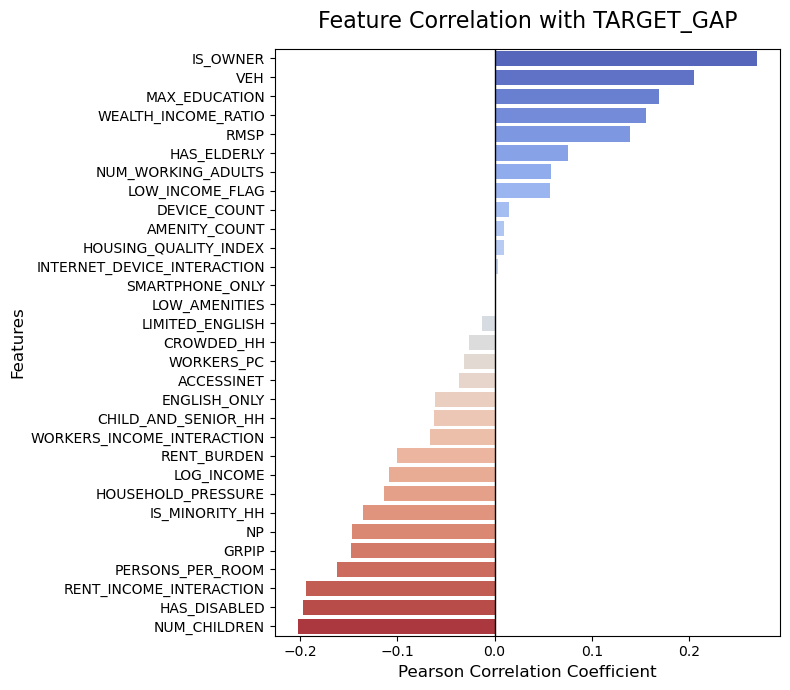

In [7]:
# %%

# 1. Prepare the dataframe for correlation
# We drop the ID, Geography, and the direct poverty proxy (POVERTY_GAP) 
# exactly as you defined for the machine learning features.
df_corr = df.drop(columns=['SERIALNO', 'PUMA', 'POVERTY_GAP']).copy()

# 2. Calculate Pearson correlation with the target variable
correlations = df_corr.corr()['TARGET_GAP'].drop('TARGET_GAP').sort_values(ascending=False)

print("\n--- Top Positive Correlations (Predicts GAP) ---")
print(correlations.head(5))
print("\n--- Top Negative Correlations (Predicts NO GAP) ---")
print(correlations.tail(5))

# 3. Visualize the Correlations
plt.figure(figsize=(8, 7))

# Create a bar plot
sns.barplot(
    x=correlations.values, 
    y=correlations.index, 
    palette=sns.color_palette("coolwarm", len(correlations))
)

plt.title('Feature Correlation with TARGET_GAP', fontsize=16, pad=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Adds a zero-line down the middle for visual clarity

plt.tight_layout()
plt.show()

### 1. People who receive SNAP


Use ['LOW_INCOME_FLAG==1'] to see how many people receive snap because this dataset does not explicitly indicating SNAP participation.

In [8]:
total_households = len(df)
low_income = df[df['LOW_INCOME_FLAG'] == 1]

print("Total households:", total_households)
print("Low-income households:", len(low_income))
print("Percentage:", len(low_income) / total_households * 100)

Total households: 7450
Low-income households: 5863
Percentage: 78.69798657718121


### 2. Poor People (LOW_INCOME_FLAG)


In [9]:
poor = df[df['LOW_INCOME_FLAG'] == 1]

print("Number of poor households:", len(poor))
print("Percentage:", len(poor) / len(df) * 100)
poor.describe()

Number of poor households: 5863
Percentage: 78.69798657718121


,PUMA,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,GRPIP,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,...,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000
mean,17268.626812,0.566263,0.403036,0.238956,0.400648,17.593723,0.466826,1.115299,1.403207,33.619649,...,0.002558,0.017397,6.425721,0.047245,0.993519,0.048780,0.859287,0.379524,0.001364,0.009040
std,25373.430957,0.495632,0.490550,0.739561,0.670563,3.797148,0.498941,0.955872,0.765026,42.389153,...,0.050520,0.214704,0.667954,0.452808,0.080252,0.215427,0.347755,0.297352,0.036917,0.094655
min,101.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,805.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000
50%,5908.000000,1.000000,0.000000,0.000000,0.000000,18.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.285714,0.000000,0.000000
75%,17700.000000,1.000000,1.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,81.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.000000,1.000000,9.000000,6.000000,24.000000,1.000000,6.000000,3.000000,101.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


In [10]:
low_income_counts = df['LOW_INCOME_FLAG'].value_counts().sort_index()
low_income_props = df['LOW_INCOME_FLAG'].value_counts(normalize=True).sort_index() * 100

print("Low-Income Household Counts:")
display(low_income_counts)

print("Low-Income Household Percentages:")
display(low_income_props)

Low-Income Household Counts:


LOW_INCOME_FLAG
0    1587
1    5863
Name: count, dtype: int64

Low-Income Household Percentages:


LOW_INCOME_FLAG
0    21.302013
1    78.697987
Name: proportion, dtype: float64

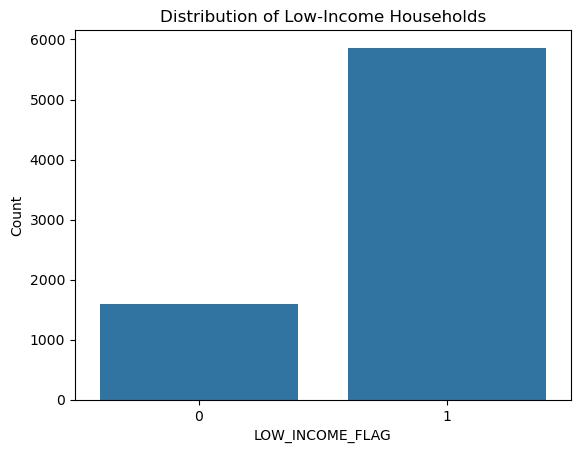

In [11]:
sns.countplot(x='LOW_INCOME_FLAG', data=df)
plt.title("Distribution of Low-Income Households")
plt.xlabel("LOW_INCOME_FLAG")
plt.ylabel("Count")
plt.show()

## Low-Income Household Analysis

The variable `LOW_INCOME_FLAG` is used in this notebook to examine low-income households within the final blind dataset.

Although `TARGET_GAP` was constructed upstream using poverty-based eligibility and SNAP receipt, `LOW_INCOME_FLAG` remains useful for comparing broader income-related differences across households.

### 3. People qualified for SNAP but NOT receiving it --> We will use TARGET_GAP == 1.
 

In [12]:
gap = df[df['TARGET_GAP'] == 1]

print("Eligible but NOT receiving SNAP:", len(gap))
print("Percentage:", len(gap) / len(df) * 100)

Eligible but NOT receiving SNAP: 4929
Percentage: 66.16107382550337


Compare with poor:

How many poor households are missing SNAP?

                  SNAP VS POVERTY

In [13]:
pd.crosstab(df['LOW_INCOME_FLAG'], df['TARGET_GAP'], normalize='index')

TARGET_GAP,False,True
LOW_INCOME_FLAG,,
0,0.390674,0.609326
1,0.324237,0.675763


### 4.Households eligible for SNAP but NOT receiving it
#### SNAP Eligibility Gap Analysis


In [14]:
gap = df[df['TARGET_GAP'] == 1]

gap.describe()

,PUMA,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,GRPIP,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,...,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000
mean,17644.400487,0.546155,0.330087,0.353621,0.569892,18.192331,0.444106,1.405559,1.328667,27.858592,...,0.002029,0.017042,6.403124,0.051735,0.993305,0.051938,0.812741,0.402675,0.001826,0.012781
std,25654.572020,0.497916,0.470292,0.898528,0.767408,3.602445,0.496916,1.040601,0.710765,40.912924,...,0.045001,0.215364,0.680490,0.477541,0.081557,0.221923,0.390159,0.326475,0.042696,0.112342
min,101.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,1003.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000
50%,5908.000000,1.000000,0.000000,0.000000,0.000000,19.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,17700.000000,1.000000,1.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,61.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.000000,1.000000,8.000000,6.000000,24.000000,1.000000,6.000000,3.000000,101.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000


In [15]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
True     0.661611
False    0.338389
Name: proportion, dtype: float64

### Characteristics of Gap Households

Descriptive statistics for households with `TARGET_GAP = 1` show the overall profile of the SNAP gap population. These households can be examined in terms of income, rent burden, number of children, elderly presence, disability, and work participation.

This summary helps identify whether the gap population is associated with financial strain and other forms of household vulnerability.

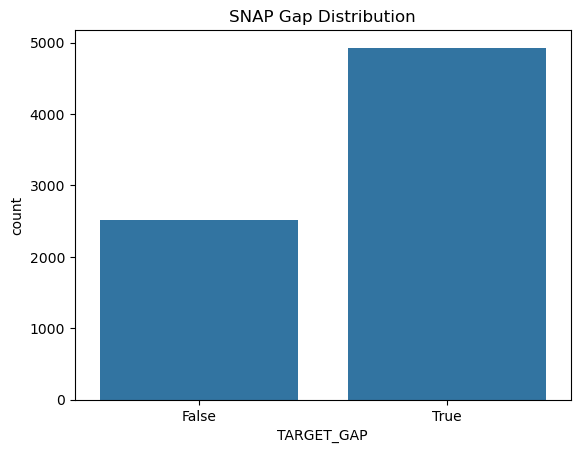

In [16]:
sns.countplot(x='TARGET_GAP', data=df)
plt.title("SNAP Gap Distribution")
plt.show()

In [17]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
True     0.661611
False    0.338389
Name: proportion, dtype: float64

###  SNAP Gap Analysis

Approximately 8% of households are eligible for SNAP but are not receiving benefits.  
This represents a critical gap in assistance programs.

### 5.Group Comparison (Gap vs Non-Gap)

In [18]:
gap_comparison = df.groupby('TARGET_GAP')[[
    'NUM_CHILDREN',
    'HAS_ELDERLY',
    'HAS_DISABLED',
    'NUM_WORKING_ADULTS',
    'LOG_INCOME',
    'RENT_BURDEN',
    'POVERTY_GAP',
    'HOUSEHOLD_PRESSURE'
]].mean()

display(gap_comparison)

,NUM_CHILDREN,HAS_ELDERLY,HAS_DISABLED,NUM_WORKING_ADULTS,LOG_INCOME,RENT_BURDEN,POVERTY_GAP,HOUSEHOLD_PRESSURE
TARGET_GAP,,,,,,,,
False,0.818326,0.466878,0.534708,0.477192,4.373433,0.372471,64.179294,1.696913
True,0.353621,0.546155,0.330087,0.569892,3.291046,0.274498,65.185636,1.483330


###  Gap vs Non-Gap Comparison

Comparing households by `TARGET_GAP` helps reveal how gap households differ from the rest of the sample.

In general, households in the SNAP gap tend to have:
- lower income
- higher rent burden
- greater signs of economic stress

This supports the interpretation that the gap population is financially vulnerable and potentially underserved.

In [19]:
gap = df[df['TARGET_GAP'] == 1]
non_gap = df[df['TARGET_GAP'] == 0]

print("Gap households:", len(gap))
print("Non-gap households:", len(non_gap))

Gap households: 4929
Non-gap households: 2521


### 6.Housing Stress Analysis

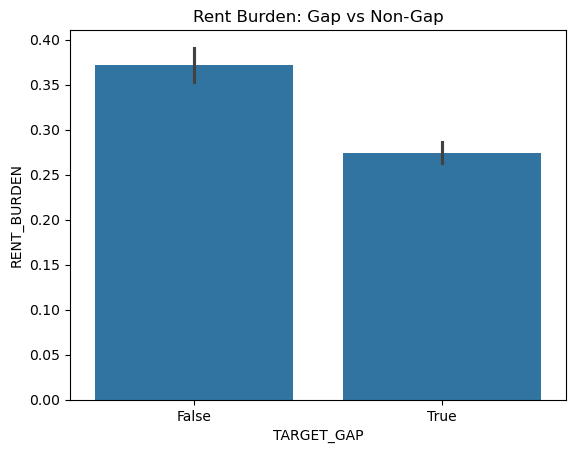

In [20]:
sns.barplot(x='TARGET_GAP', y='RENT_BURDEN', data=df)
plt.title("Rent Burden: Gap vs Non-Gap")
plt.show()

### Housing Burden

Households in the SNAP gap experience significantly higher rent burden, 
indicating increased financial stress and housing instability.

### 7. Children Analysis
#### Average number of children per household

In [21]:
avg_children = df['NUM_CHILDREN'].mean()
print("Average number of children per household:", avg_children)

Average number of children per household: 0.5108724832214765


In [22]:
df['NUM_CHILDREN'].describe()

count    7450.000000
mean        0.510872
std         1.084658
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: NUM_CHILDREN, dtype: float64

# Do poor households have more children?

##### By income group:

In [23]:
df.groupby('LOW_INCOME_FLAG')['NUM_CHILDREN'].mean()

LOW_INCOME_FLAG
0    1.515438
1    0.238956
Name: NUM_CHILDREN, dtype: float64

In [24]:
df['LOW_INCOME_FLAG'].value_counts()

LOW_INCOME_FLAG
1    5863
0    1587
Name: count, dtype: int64

In [25]:
df.groupby('LOW_INCOME_FLAG')['LOG_INCOME'].mean()

LOW_INCOME_FLAG
0    10.189440
1     1.889195
Name: LOG_INCOME, dtype: float64

###  Children and Household Structure

The average number of children per household provides an additional view of household composition. When comparing income groups, the results suggest that low-income households in this dataset may have fewer children on average than expected.

This pattern should be interpreted together with elderly presence and other demographic factors, since poverty in this dataset may be linked to older or smaller households rather than larger family size alone.

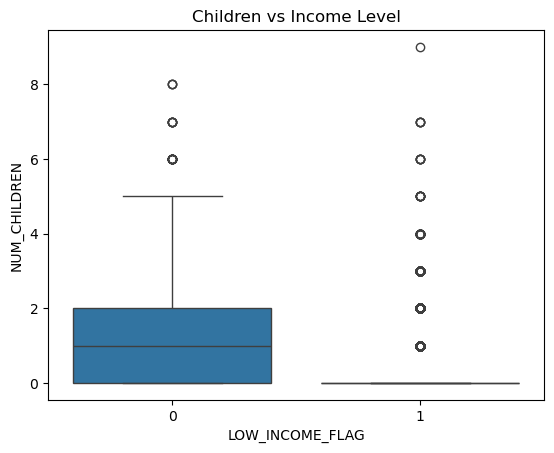

In [26]:
sns.boxplot(x='LOW_INCOME_FLAG', y='NUM_CHILDREN', data=df)
plt.title("Children vs Income Level")
plt.show()

### 8.Elderly Analysis

In [27]:
df.groupby('LOW_INCOME_FLAG')['HAS_ELDERLY'].mean()

LOW_INCOME_FLAG
0    0.345936
1    0.566263
Name: HAS_ELDERLY, dtype: float64

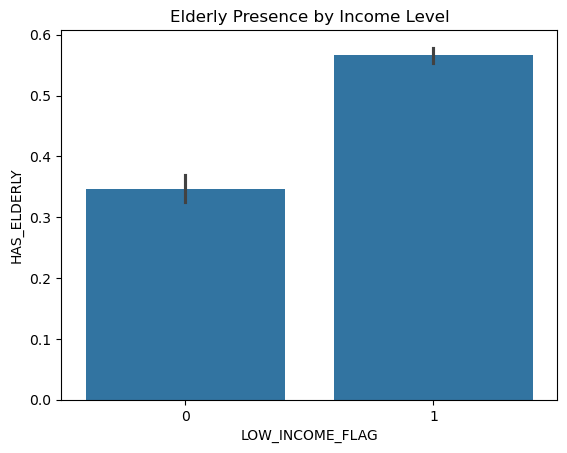

In [28]:
sns.barplot(x='LOW_INCOME_FLAG', y='HAS_ELDERLY', data=df)
plt.title("Elderly Presence by Income Level")
plt.show()

### Elderly Presence

The analysis shows that elderly presence is an important dimension of household vulnerability. A higher share of elderly households among low-income or gap households may help explain why some groups have fewer children while still experiencing financial hardship.

This suggests that economic vulnerability in the dataset is not limited to households with children, but also includes aging households.

### 9. Poverty and gap cross-tab

In [29]:
poverty_gap_table = pd.crosstab(
    df['LOW_INCOME_FLAG'],
    df['TARGET_GAP'],
    normalize='index'
)

display(poverty_gap_table)

TARGET_GAP,False,True
LOW_INCOME_FLAG,,
0,0.390674,0.609326
1,0.324237,0.675763


### 10. Income Distribution

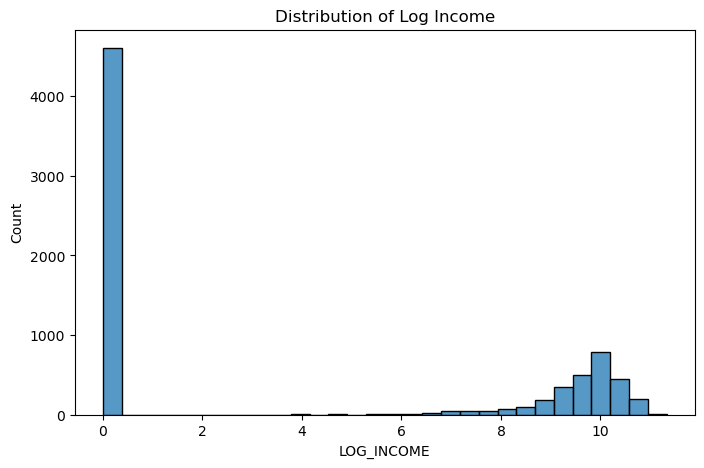

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df['LOG_INCOME'], bins=30)
plt.title("Distribution of Log Income")
plt.xlabel("LOG_INCOME")
plt.ylabel("Count")
plt.show()

### 11. Correlation Heatmap

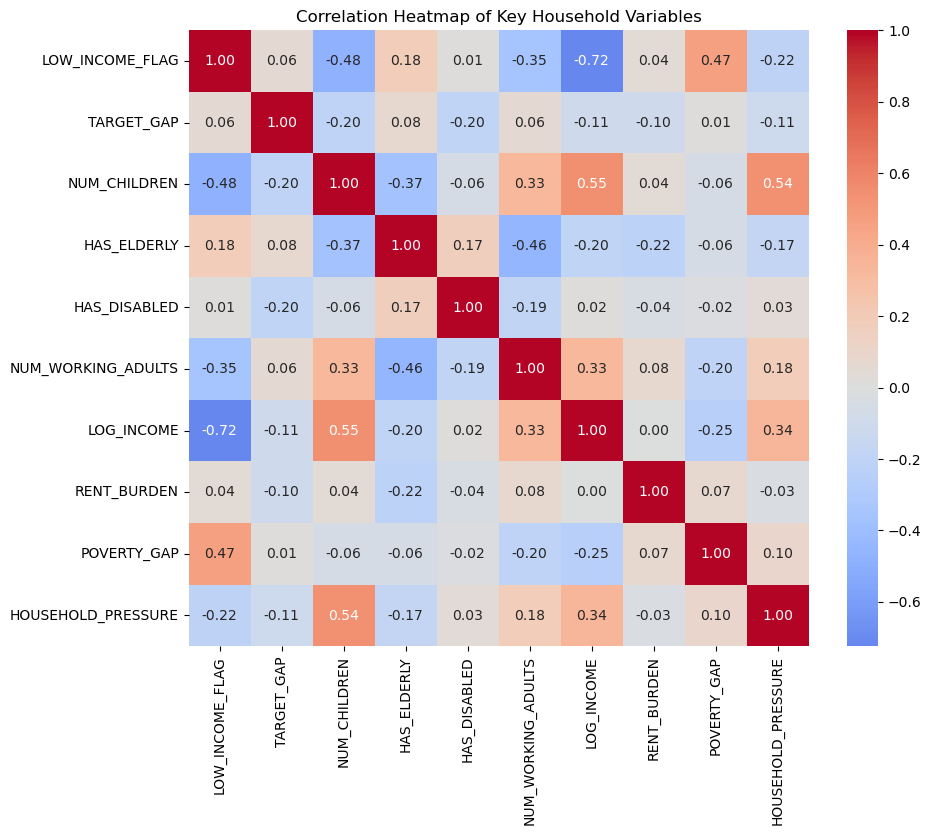

In [31]:

cols = [
    'LOW_INCOME_FLAG', 'TARGET_GAP', 'NUM_CHILDREN', 'HAS_ELDERLY',
    'HAS_DISABLED', 'NUM_WORKING_ADULTS', 'LOG_INCOME',
    'RENT_BURDEN', 'POVERTY_GAP', 'HOUSEHOLD_PRESSURE'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap of Key Household Variables")
plt.show()

###  Explain Correlation Map

The correlation heatmap highlights the strongest relationships among income, poverty-related indicators, housing burden, and household composition.

Key patterns suggest that:
- lower income is closely associated with low-income status
- SNAP gap households are associated with higher poverty-related stress
- rent burden is positively related to economic hardship
- elderly presence and number of children reflect different household structures

Overall, the correlation analysis supports the conclusion that households in the SNAP gap face meaningful socioeconomic disadvantage.

### 12.Data Limitation



The final blind dataset does not include the original raw variables for SNAP receipt (`FS`) or poverty ratio (`POVPIP`). However, the variable `TARGET_GAP` was created before blinding using those upstream fields.

Specifically, `TARGET_GAP = 1` was defined using eligibility-related poverty status together with non-receipt of SNAP. Therefore, the gap analysis in this notebook is based on a constructed target derived from original SNAP and poverty information, rather than a purely indirect proxy.

### 13.Final Conclusion

This exploratory analysis identifies an important group of households that fall into the SNAP eligibility gap, represented by `TARGET_GAP = 1`. These households were defined upstream as likely eligible for SNAP based on poverty-related criteria but not receiving benefits.

The results suggest that gap households experience clear socioeconomic disadvantage, including lower income and greater housing burden. The analysis also shows that household vulnerability may take different forms, including elderly presence and smaller household structure.

Overall, the findings highlight the importance of understanding not only poverty, but also program non-participation among households that may qualify for assistance.

## -------------------------

# Exploratory Data Analysis (EDA)

## Objective
The goal of this analysis is to explore the distributional differences between households that fall into the SNAP participation gap (`TARGET_GAP = 1`) and those that do not (`TARGET_GAP = 0`). 

In particular, we aim to understand how key household characteristics (X variables) differ across these two groups. These differences can provide insights into structural and socioeconomic factors associated with the gap population.

---

## Approach
We divide the dataset into two groups:
- **Gap Group (TARGET_GAP = 1):** Households that are likely eligible but not receiving SNAP benefits.
- **Non-Gap Group (TARGET_GAP = 0):** Households that are not in the gap.

To compare these groups, we analyze the distribution of selected variables using:
- **Histograms** to visualize distribution overlap
- **Boxplots** to highlight differences in central tendency and spread

---

## Variables of Interest
The analysis focuses on key variables that capture household structure, economic pressure, and access to resources:

- **NUM_CHILDREN:** Number of children in the household  
- **VEH:** Number of vehicles (proxy for mobility/access)  
- **RENT_BURDEN:** Housing cost pressure relative to income  
- **HOUSEHOLD_PRESSURE:** Composite indicator of financial stress  
- **PERSONS_PER_ROOM:** Measure of overcrowding  

---

## Expected Insights
Through this analysis, we aim to identify patterns such as:
- Whether gap households experience higher financial stress  
- Differences in family size and dependency burden  
- Potential access limitations (e.g., transportation, housing conditions)

These insights will help guide further modeling and policy-oriented analysis.

## Split The group

In [32]:
df_gap = df[df['TARGET_GAP'] == 1]
df_non_gap = df[df['TARGET_GAP'] == 0]

## Number of Children

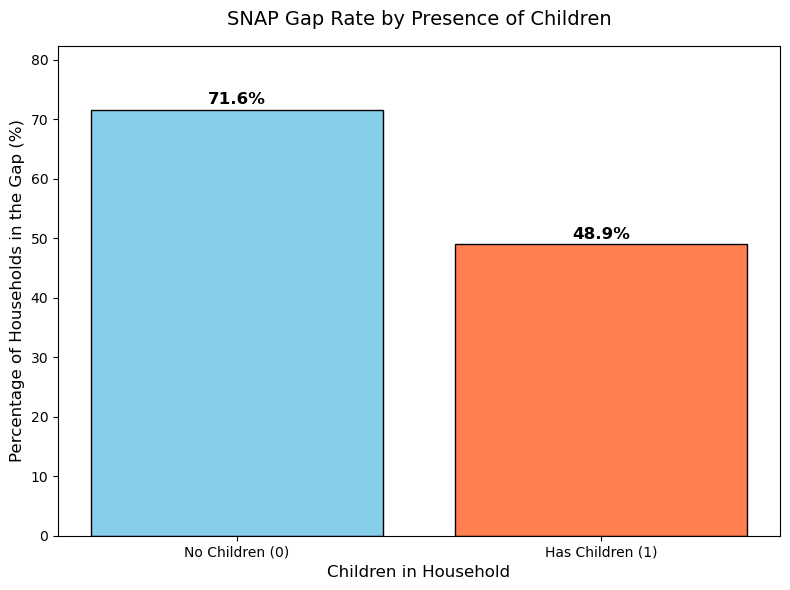

In [33]:
# 1. Remove missing values
df_nc = df.dropna(subset=['NUM_CHILDREN'])

# 2. Create a binary group (e.g., households with children vs no children)
df_nc['HAS_CHILDREN'] = (df_nc['NUM_CHILDREN'] > 0).astype(int)

# 3. Calculate gap rate (%) for each group
gap_rates = df_nc.groupby('HAS_CHILDREN')['TARGET_GAP'].mean() * 100

# 4. Plot bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['No Children (0)', 'Has Children (1)'],
    [gap_rates.get(0, 0), gap_rates.get(1, 0)],
    color=['skyblue', 'coral'],
    edgecolor='black'
)

# 5. Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# 6. Formatting
plt.title('SNAP Gap Rate by Presence of Children', fontsize=14, pad=15)
plt.ylabel('Percentage of Households in the Gap (%)', fontsize=12)
plt.xlabel('Children in Household', fontsize=12)

plt.ylim(0, max(gap_rates) * 1.15)

plt.tight_layout()
plt.show()

### Number of Children

The distribution of the number of children indicates that households in the **TARGET_GAP = 1** group tend to have slightly larger family sizes compared to non-gap households.

This pattern suggests that households with more dependents may face increased financial pressure, which could contribute to their likelihood of falling into the SNAP participation gap.

Larger household size may therefore be an important factor in understanding unmet assistance needs.

## Rent

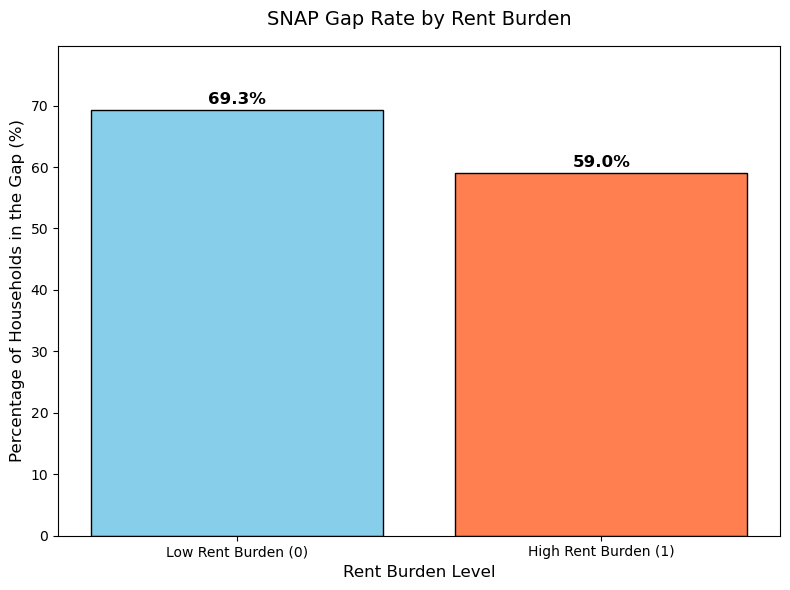

In [34]:
# 1. Remove missing values
df_rb = df.dropna(subset=['RENT_BURDEN'])

# 2. Create a binary flag (high vs low rent burden using median)
threshold = df_rb['RENT_BURDEN'].median()
df_rb['HIGH_RENT_BURDEN'] = (df_rb['RENT_BURDEN'] > threshold).astype(int)

# 3. Calculate gap rate (%) for each group
gap_rates = df_rb.groupby('HIGH_RENT_BURDEN')['TARGET_GAP'].mean() * 100

# 4. Plot bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['Low Rent Burden (0)', 'High Rent Burden (1)'],
    [gap_rates.get(0, 0), gap_rates.get(1, 0)],
    color=['skyblue', 'coral'],
    edgecolor='black'
)

# 5. Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# 6. Formatting
plt.title('SNAP Gap Rate by Rent Burden', fontsize=14, pad=15)
plt.ylabel('Percentage of Households in the Gap (%)', fontsize=12)
plt.xlabel('Rent Burden Level', fontsize=12)

plt.ylim(0, max(gap_rates) * 1.15)

plt.tight_layout()
plt.show()

### Rent Burden Analysis

The distribution of rent burden shows a clear difference between the two groups. Households in the **TARGET_GAP = 1** group tend to experience higher rent burden compared to those in the non-gap group.

This suggests that gap households face greater housing cost pressure relative to their income. Additionally, the wider spread of the distribution indicates variability in financial stress within this group.

Overall, higher rent burden appears to be a strong indicator associated with households that are eligible but not receiving SNAP benefits.

## VEH (Number of Cars)

In [35]:
df['HAS_CAR'] = (df['VEH'] > 0).astype(int)

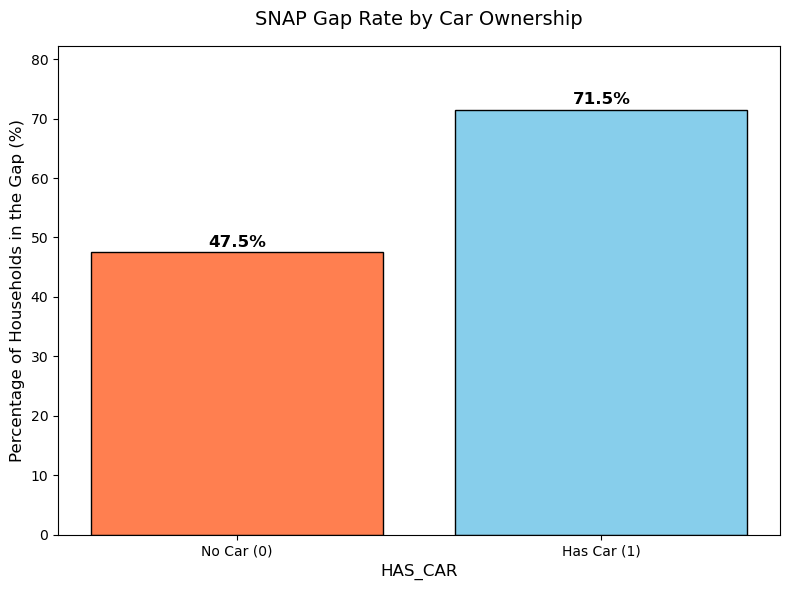

In [36]:
# 1. Remove missing values if any
df_car = df.dropna(subset=['HAS_CAR'])

# 2. Calculate gap rate (%) for each car ownership group
gap_rates = df_car.groupby('HAS_CAR')['TARGET_GAP'].mean() * 100

# 3. Plot bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['No Car (0)', 'Has Car (1)'],
    [gap_rates.get(0, 0), gap_rates.get(1, 0)],
    color=['coral', 'skyblue'],
    edgecolor='black'
)

# 4. Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# 5. Formatting
plt.title('SNAP Gap Rate by Car Ownership', fontsize=14, pad=15)
plt.ylabel('Percentage of Households in the Gap (%)', fontsize=12)
plt.xlabel('HAS_CAR', fontsize=12)

plt.ylim(0, max(gap_rates) * 1.15)

plt.tight_layout()
plt.show()

### Vehicle Ownership

The distribution of vehicle ownership shows that households in the **TARGET_GAP = 1** group generally have fewer vehicles compared to non-gap households.

This may indicate limited transportation access, which could act as a barrier to accessing resources, including SNAP enrollment services.

Lower vehicle ownership may therefore be associated with reduced mobility and increased vulnerability among gap households.

### Household Pressure

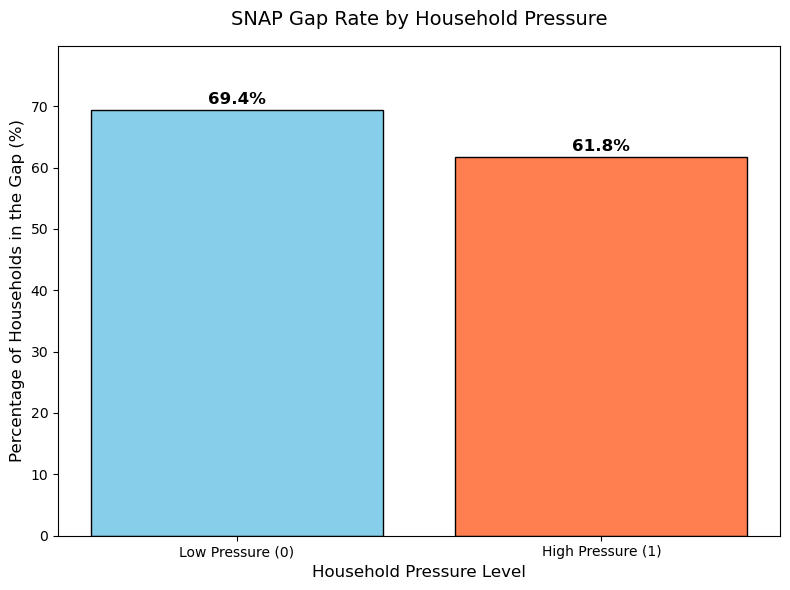

In [37]:
# 1. Remove missing values
df_hp = df.dropna(subset=['HOUSEHOLD_PRESSURE'])

# 2. Create a binary flag (e.g., high pressure vs low pressure using median)
threshold = df_hp['HOUSEHOLD_PRESSURE'].median()
df_hp['HIGH_PRESSURE'] = (df_hp['HOUSEHOLD_PRESSURE'] > threshold).astype(int)

# 3. Calculate gap rate (%) for each pressure group
gap_rates = df_hp.groupby('HIGH_PRESSURE')['TARGET_GAP'].mean() * 100

# 4. Plot bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['Low Pressure (0)', 'High Pressure (1)'],
    [gap_rates.get(0, 0), gap_rates.get(1, 0)],
    color=['skyblue', 'coral'],
    edgecolor='black'
)

# 5. Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# 6. Formatting
plt.title('SNAP Gap Rate by Household Pressure', fontsize=14, pad=15)
plt.ylabel('Percentage of Households in the Gap (%)', fontsize=12)
plt.xlabel('Household Pressure Level', fontsize=12)

plt.ylim(0, max(gap_rates) * 1.15)

plt.tight_layout()
plt.show()

### Household Pressure

The distribution of the household pressure variable reveals that **TARGET_GAP = 1** households tend to experience higher overall pressure compared to non-gap households.

This suggests that gap households face compounded socioeconomic stress, potentially combining factors such as income constraints, household size, and resource limitations.

This variable provides a strong aggregated signal of vulnerability and is highly informative for distinguishing gap households.

## PERSONS_PER_ROOM

/var/folders/0s/d2ycgfq576zdm73qwlf4r6gc0000gn/T/ipykernel_53785/4146486745.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  no_gap_pct = gap_percentages.get(0, 0)
/var/folders/0s/d2ycgfq576zdm73qwlf4r6gc0000gn/T/ipykernel_53785/4146486745.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gap_pct = gap_percentages.get(1, 0)


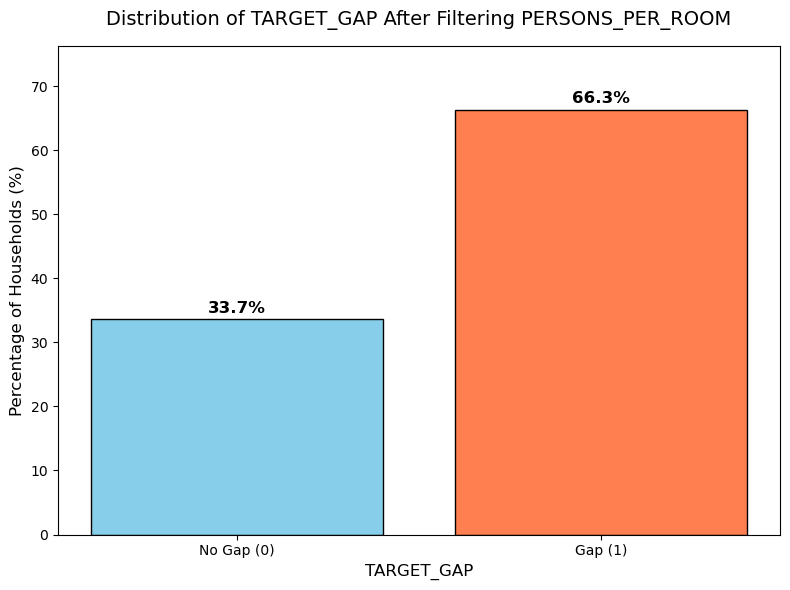

In [38]:
# 1. Remove extreme outliers (top 1%)
threshold = df['PERSONS_PER_ROOM'].quantile(0.99)
df_filtered = df[df['PERSONS_PER_ROOM'] <= threshold]

# 2. Calculate percentage of households by TARGET_GAP
gap_percentages = df_filtered['TARGET_GAP'].value_counts(normalize=True).sort_index() * 100

# Make sure both classes exist
no_gap_pct = gap_percentages.get(0, 0)
gap_pct = gap_percentages.get(1, 0)

# 3. Create bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['No Gap (0)', 'Gap (1)'],
    [no_gap_pct, gap_pct],
    color=['skyblue', 'coral'],
    edgecolor='black'
)

# 4. Add percentage labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# 5. Formatting
plt.title('Distribution of TARGET_GAP After Filtering PERSONS_PER_ROOM', fontsize=14, pad=15)
plt.ylabel('Percentage of Households (%)', fontsize=12)
plt.xlabel('TARGET_GAP', fontsize=12)
plt.ylim(0, max(no_gap_pct, gap_pct) * 1.15)

plt.tight_layout()
plt.show()

## Language Households 

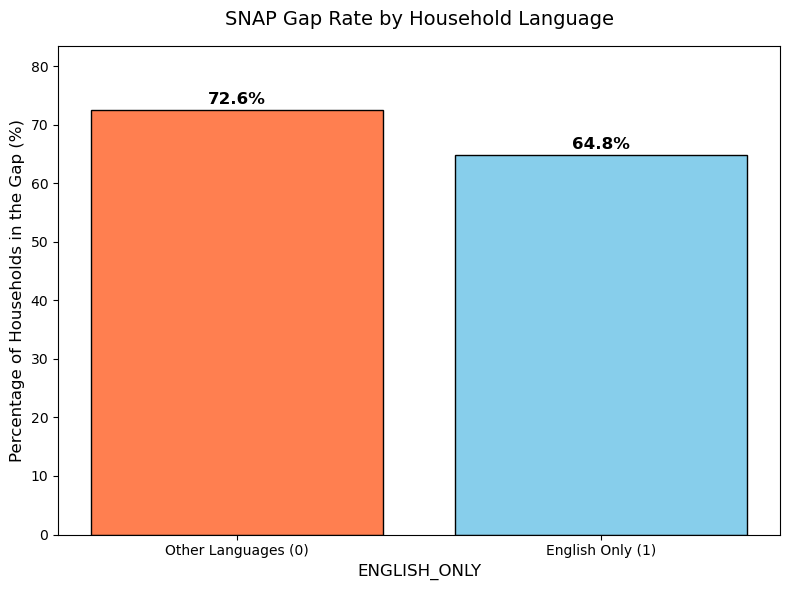

In [39]:

# 1. Calculate the percentage of households in the Gap for each language group
# Since TARGET_GAP is 0 or 1, taking the mean() gives the proportion (multiply by 100 for percentage)
gap_rates = df.groupby('ENGLISH_ONLY')['TARGET_GAP'].mean() * 100

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
# gap_rates[0] is Non-English/Multilingual, gap_rates[1] is English Only
bars = plt.bar(['Other Languages (0)', 'English Only (1)'], 
               [gap_rates[0], gap_rates[1]], 
               color=['coral', 'skyblue'], 
               edgecolor='black')

# 3. Add percentage labels on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 4. Formatting
plt.title('SNAP Gap Rate by Household Language', fontsize=14, pad=15)
plt.ylabel('Percentage of Households in the Gap (%)', fontsize=12)
plt.xlabel('ENGLISH_ONLY', fontsize=12)

# Give the y-axis a little extra headroom so the labels fit nicely
plt.ylim(0, max(gap_rates) + (max(gap_rates) * 0.15)) 

plt.tight_layout()
plt.show()